# Draw Bbox

In [15]:
import cv2

def draw_bboxes(img, true_bboxes=[], pred_bboxes=[], true_box_color=(0,255,0), pred_box_color=(255,0,0), thickness=1):
    img2 = img.copy()
    for xc, yc, w, h in true_bboxes:
        x0, y0, x1, y1 = int(xc - 0.5*w), int(yc - 0.5*h), int(xc + 0.5*w), int(yc + 0.5*h)
        img2 = cv2.rectangle(img2, (x0, y0), (x1, y1), color=true_box_color, thickness=thickness)
    for xc, yc, w, h in pred_bboxes:
        x0, y0, x1, y1 = int(xc - 0.5*w), int(yc - 0.5*h), int(xc + 0.5*w), int(yc + 0.5*h)
        img2 = cv2.rectangle(img2, (x0, y0), (x1, y1), color=pred_box_color, thickness=thickness)
    return img2

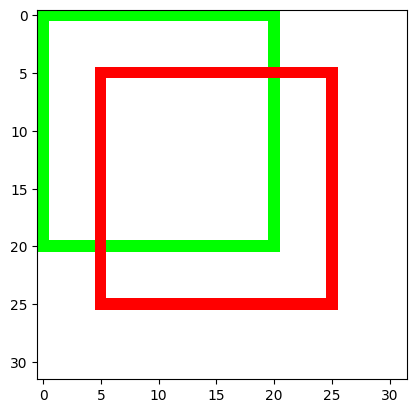

In [16]:
if __name__=='__main__':
    import numpy as np
    import matplotlib.pyplot as plt

    img = np.full((32,32,3), 255, dtype=np.uint8)
    true_bboxes = [[10, 10, 20, 20]]
    pred_bboxes = [[15, 15, 20, 20]]

    img2 = draw_bboxes(img, true_bboxes=true_bboxes, pred_bboxes=pred_bboxes)

    plt.imshow(img2)
    plt.show()

# Generate Random Sample

In [17]:
import numpy as np
import random
from PIL import Image, ImageDraw, ImageFont
import copy

def draw_text_on_image(
    img, text, xy, text_xy = {
        '0':(-1,1, 5,9), 
        '1':(-1,1, 6,9), 
        '2':(-1,1, 5,9), 
        '3':(-1,1, 5,9), 
        '4':(-1,1, 6,9), 
        '5':(-1,1, 5,9), 
        '6':(-1,1, 5,9), 
        '7':(-1,1, 5,9), 
        '8':(-1,1, 5,9), 
        '9':(-1,1, 5,9), 
    }):
    #--- offset adjustment ---------------
    x0, y0, x1, y1 = text_xy[text]
    x, y = xy
    xx, yy = x - 0.5*(x0 + x1), y - 0.5*(y0 + y1)
    x0, y0, x1, y1 = x0 + xx, y0 + yy, x1 + xx, y1 + yy

    img_new = copy.deepcopy(img)
    draw = ImageDraw.ImageDraw(img_new)
    draw.text((xx, yy), text, fill=0)#, font=ImageFont.truetype('arial.ttf', 30))
#     draw.text((xx, yy), text, fill=0, font=ImageFont.truetype('Gidole-Regular.ttf', 30))

    x0_y0_x1_y1 = (x0, y0, x1, y1)
    bbox = (0.5*(x0 + x1), 0.5*(y0 + y1), (x1 - x0), (y1 - y0))

    return img_new, bbox, x0_y0_x1_y1

def generate_random_sample(
    GRID_W = 2, GRID_H = 2, 
    UPIXEL_W = 32, UPIXEL_H = 32,
    LABELS = ['0','1','2','3','4','5','6','7','8','9'],
    min_num_digits=0, max_num_digits=float('inf'),
    draw_bbox=False,
    ):
    
    IMAGE_W, IMAGE_H = GRID_W * UPIXEL_W, GRID_H * UPIXEL_H

    grid_points = [(x,y) for x in range(GRID_W) for y in range(GRID_H)]

    img = Image.fromarray(np.full((IMAGE_H, IMAGE_W, 3), 255, 'uint8')) # initialize image
    
#     num_digits = random.choice([1,2,3,4,5][:len(grid_points)]) # always contains digits
    num_digits = random.choice([0,1,2,3,4,5][:(len(grid_points) + 1)])
    num_digits = random.randint(max(0, min_num_digits), min(len(grid_points), max_num_digits))
    random_grid_points = random.sample(grid_points, k=num_digits)
    info = []
    for j in range(num_digits):
        digit = random.choice(LABELS)
        gx, gy = random_grid_points.pop()
        dx, dy = random.uniform(0.01, 0.99), random.uniform(0.01, 0.99)
        xx, yy = (gx + dx) * UPIXEL_W, (gy + dy) * UPIXEL_H

        img, bbox, _ = draw_text_on_image(img, digit, (xx,yy))

        if draw_bbox: 
            ImageDraw.ImageDraw(img).rectangle((bbox[0]-bbox[2]/2, bbox[1]-bbox[3]/2, bbox[0]+bbox[2]/2, bbox[1]+bbox[3]/2), outline='green')

        info.append({'digit':digit, 'bbox':bbox})

    sample = {'image':img, 'info':info}

    return sample

[{'digit': '5', 'bbox': (29.997055567940883, 37.30780722378086, 6.0, 8.0)}, {'digit': '4', 'bbox': (11.189210729431636, 8.721994044606095, 7.0, 8.0)}, {'digit': '8', 'bbox': (40.135578818203925, 5.342408952288761, 6.0, 8.0)}, {'digit': '9', 'bbox': (41.449894474663864, 44.4243351729606, 6.0, 8.0)}]


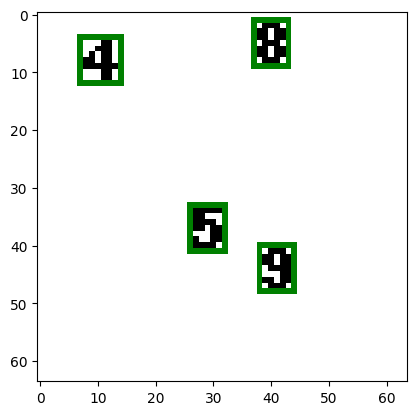

In [18]:
if __name__=='__main__':
    import matplotlib.pyplot as plt

#     random.seed(1234)

    sample = generate_random_sample(draw_bbox=True)
    
    print(sample['info'])
    plt.imshow(sample['image'])
    plt.show()

# Dataset for PyTorch

In [19]:
import torch
from torch.utils.data import Dataset, DataLoader

class SimpleDigitsDataset(Dataset):
    def __init__(
        self, num_real_time_samples=1,
        GRID_H = 2, GRID_W = 2, 
        UPIXEL_H = 32, UPIXEL_W = 32, 
        LABELS = ['0','1','2','3','4','5','6','7','8','9'],
        min_num_digits=0, max_num_digits=float('inf'),
        NORMALIZE_IMAGE = False, NORMALIZE_PIXEL_BBOX=False,
        ):
        self.num_real_time_samples = num_real_time_samples
        self.GRID_H = GRID_H
        self.GRID_W = GRID_W
        self.UPIXEL_H = UPIXEL_H
        self.UPIXEL_W = UPIXEL_W
        self.LABELS = LABELS
        self.min_num_digits = min_num_digits
        self.max_num_digits = max_num_digits
        self.NORMALIZE_IMAGE = NORMALIZE_IMAGE
        self.NORMALIZE_PIXEL_BBOX = NORMALIZE_PIXEL_BBOX
        return

    def __len__(self):
        return self.num_real_time_samples

    def __getitem__(self, index):
        sample = generate_random_sample(GRID_W=self.GRID_W, GRID_H=self.GRID_H, UPIXEL_W=self.UPIXEL_W, UPIXEL_H=self.UPIXEL_H, LABELS=self.LABELS, min_num_digits=self.min_num_digits, max_num_digits=self.max_num_digits, draw_bbox=False)

        pixel_conf = np.zeros((self.GRID_H, self.GRID_W), dtype='float')
        pixel_bbox = np.zeros((self.GRID_H, self.GRID_W, 4), dtype='float')

        for info in sample['info']:
            xc, yc, w, h = info['bbox']

            nx, rx = divmod(xc/self.UPIXEL_W, 1)
            ny, ry = divmod(yc/self.UPIXEL_H, 1)
            nx, ny = int(nx), int(ny)
            rw, rh = w/self.UPIXEL_W, h/self.UPIXEL_H

            pixel_conf[ny, nx] = 1.0 # box confidence
            pixel_bbox[ny, nx, 0] = rx if self.NORMALIZE_PIXEL_BBOX else xc
            pixel_bbox[ny, nx, 1] = ry if self.NORMALIZE_PIXEL_BBOX else yc
            pixel_bbox[ny, nx, 2] = rw if self.NORMALIZE_PIXEL_BBOX else w
            pixel_bbox[ny, nx, 3] = rh if self.NORMALIZE_PIXEL_BBOX else h
            # y_batch[i, ny, nx, 0, 5 + LABELS.index(info['digit'])] = 1.0

        return {
            'image':np.array(sample['image']) / (255.0 if self.NORMALIZE_IMAGE else 1.0),
            'pixel_conf':pixel_conf,
            'pixel_bbox':pixel_bbox,
        }

    def reverse_normalize(self, sample):
        reversed_sample = {}
        for k in sample.keys():
            if (k == 'image') and self.NORMALIZE_IMAGE:
                reversed_sample[k] = (sample[k] * 255.0).astype(np.uint8) # reverse_normalize

            elif (k == 'pixel_bbox') and self.NORMALIZE_PIXEL_BBOX:
                pixel_bbox = np.zeros_like(sample[k])
                for i in range(self.GRID_H):
                    for j in range(self.GRID_W):
                        conf = (sample['pixel_conf'][i,j] > 0.5)

                        pixel_bbox[i,j,0] = conf * (sample[k][i,j,0] + j) * self.UPIXEL_W # reverse_normalize
                        pixel_bbox[i,j,1] = conf * (sample[k][i,j,1] + i) * self.UPIXEL_H # reverse_normalize
                        pixel_bbox[i,j,2] = conf * sample[k][i,j,2] * self.UPIXEL_W # reverse_normalize
                        pixel_bbox[i,j,3] = conf * sample[k][i,j,3] * self.UPIXEL_H # reverse_normalize
                reversed_sample[k] = pixel_bbox

            else:
                reversed_sample[k] = sample[k]
            
        return reversed_sample

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


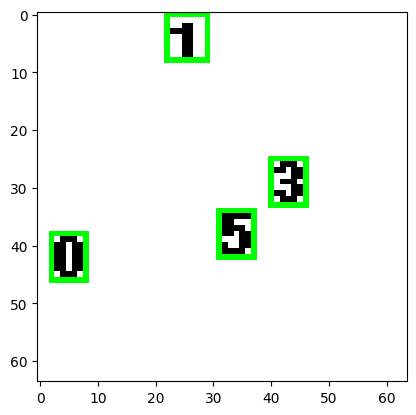

sample['pixel_conf'] = [[1. 1.]
 [1. 1.]]
sample['pixel_bbox'] = [[[25.97537888  4.75487636  7.          8.        ]
  [43.16484286 29.36365915  6.          8.        ]]

 [[ 5.38886095 42.59656575  6.          8.        ]
  [34.21011484 38.91534964  6.          8.        ]]]
s['pixel_bbox'] = [[[25.97537888  4.75487636  7.          8.        ]
  [43.16484286 29.36365915  6.          8.        ]]

 [[ 5.38886095 42.59656575  6.          8.        ]
  [34.21011484 38.91534964  6.          8.        ]]]


In [20]:
if __name__ == '__main__':
    dataset = SimpleDigitsDataset(num_real_time_samples=1)
    s = dataset[0]
    sample = dataset.reverse_normalize(s)

    true_bboxes = [sample['pixel_bbox'][i,j] for h,w,_ in [sample['pixel_bbox'].shape] for i in range(h) for j in range(w) if sample['pixel_conf'][i,j] >= 0.5]
    img_bboxes = draw_bboxes(sample['image'], true_bboxes=true_bboxes)

    plt.imshow(img_bboxes)
    plt.show()
    print("sample['pixel_conf'] =", sample['pixel_conf'])
    print("sample['pixel_bbox'] =", sample['pixel_bbox'])
    print("s['pixel_bbox'] =", s['pixel_bbox'])

# Dataset for Tensorflow

(1, 64, 64, 3)
(1, 2, 2, 1, 15)
[[[[[0.40280907 0.87146968 0.21875    0.25       1.         0.
     1.         0.         0.         0.         0.         0.
     0.         0.         0.        ]]

   [[0.18065611 0.82977378 0.21875    0.25       1.         0.
     1.         0.         0.         0.         0.         0.
     0.         0.         0.        ]]]


  [[[0.         0.         0.         0.         0.         0.
     0.         0.         0.         0.         0.         0.
     0.         0.         0.        ]]

   [[0.60437425 0.91899146 0.1875     0.25       1.         0.
     0.         0.         0.         0.         0.         1.
     0.         0.         0.        ]]]]]


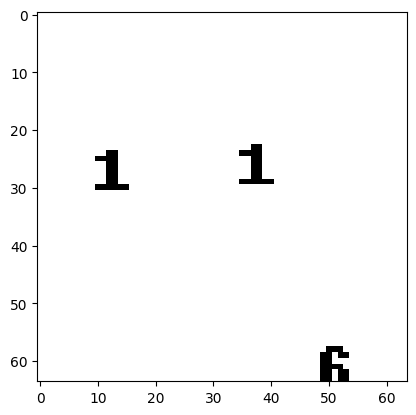

In [21]:
def data_generator(
    batch_size=16,
    GRID_W = 2, GRID_H = 2, 
    UPIXEL_W = 32, UPIXEL_H = 32,
    LABELS = ['0','1','2','3','4','5','6','7','8','9'],
    ANCHORS = [1.0, 1.0],
    ):
    
    IMAGE_W, IMAGE_H = GRID_W * UPIXEL_W, GRID_H * UPIXEL_H
    CLASS = len(LABELS)
    BOX = len(ANCHORS)//2

    while True:
        # x_batch = np.zeros((batch_size, IMAGE_H, IMAGE_W, 3))
        # y_batch = np.zeros((batch_size, GRID_H, GRID_W, BOX, 4 + 1 + CLASS))
        x_batch = np.zeros((batch_size, IMAGE_H, IMAGE_W, 3), dtype='float64')
        y_batch = np.zeros((batch_size, GRID_H, GRID_W, BOX, 4 + 1 + CLASS), dtype='float64')
        
        for i in range(batch_size):
            sample = generate_random_sample(draw_bbox=False)
            
            x_batch[i,...] = np.array(sample['image']) / 255. # normalize image
            
            for info in sample['info']:
                xh, yh, w, h = info['bbox']
                # print(k, info['bbox'])

                nx, rx = divmod(xh/UPIXEL_W, 1)
                ny, ry = divmod(yh/UPIXEL_H, 1)
                nx, ny = int(nx), int(ny)
                rw, rh = w/UPIXEL_W, h/UPIXEL_H
                y_batch[i, ny, nx, 0, 0] = rx
                y_batch[i, ny, nx, 0, 1] = ry
                y_batch[i, ny, nx, 0, 2] = rw
                y_batch[i, ny, nx, 0, 3] = rh
                y_batch[i, ny, nx, 0, 4] = 1.0 # box confidence
                y_batch[i, ny, nx, 0, 5 + LABELS.index(info['digit'])] = 1.0
            
        yield {'image':x_batch}, {'out':y_batch}

if __name__=='__main__':
    images, outs = next(data_generator(1))
    print(images['image'].shape)
    print(outs['out'].shape)
    print(outs['out'])
    plt.imshow(images['image'][0])
    plt.show()